# 04B - Sobreajuste y diagnosticos de arboles

Auditoria complementaria del top operativo definido en el notebook 04. No entrena ni predice.


In [1]:
from pathlib import Path
import sys
import json

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Force an interactive notebook backend when running cells manually.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass
from IPython.display import Markdown, Image, display

try:
    import seaborn as sns
except ImportError:
    sns = None

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

PALETTE = {
    "xgboost": "#2F6F9F",
    "random_forest": "#3A9D5D",
    "hist_gradient_boosting": "#B7791F",
    "logistic_regression": "#7B61A8",
    "wr": "#A8324A",
    "candidate": "#2F6F9F",
    "negative": "#6B7280",
    "muted": "#6B7280",
}

def require_path(path):
    path = Path(path)
    if not path.is_absolute():
        path = ROOT / path
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def pct(value):
    return "-" if pd.isna(value) else f"{100 * float(value):.1f}%"

def model_display(row):
    variant = str(row.get("dataset_variant", ""))
    family = "Relaxed" if variant.startswith("relaxed") else "Strict"
    dataset = variant.replace("relaxed_", "").replace("strict_", "")
    dataset = dataset.replace("photometry", "Phot").replace("parallax_soft", "Parallax+").replace("poe_", "POE>=")
    feat = "+err" if str(row.get("feature_set", "")).endswith("error") else "base"
    model = {"xgboost": "XGB", "random_forest": "RF", "hist_gradient_boosting": "HGB", "logistic_regression": "LogReg"}.get(str(row.get("model", "")), str(row.get("model", "")))
    sampler = {"smote": "SMOTE", "smote_enn": "SMOTE-ENN", "none": "sin sampler"}.get(str(row.get("sampler", "")), str(row.get("sampler", "")))
    return f"{model} {sampler} | {family} {dataset} | {feat}"

def add_model_columns(df):
    out = df.copy()
    out["model_label"] = out.apply(model_display, axis=1)
    for k in [50, 100, 500, 1000]:
        c = f"holdout_wr_at_{k}"
        if c in out.columns:
            out[f"{c}_pct"] = out[c] / out["wr_holdout"].replace(0, np.nan)
    return out

def rank_models(df, k=100):
    return df.sort_values(
        [f"holdout_wr_at_{k}_pct", "holdout_average_precision", "holdout_recall_at_100", "holdout_f2_wr"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)

results = add_model_columns(results)
ranked = rank_models(results, k=100)
print(f"Configuraciones evaluadas: {len(results)}")
print(f"Aceptadas: {int(results['selection_status'].eq('accepted').sum())}")
print("WR holdout por variante:")
display(results.drop_duplicates("dataset_variant").set_index("dataset_variant")["wr_holdout"].sort_index())


NameError: name 'results' is not defined

## Seleccion de corrida

Esta seccion lista las corridas sincronizadas en `training_history.duckdb`. Define `TRAINING_RUN_ID` con una de las IDs disponibles para revisar un entrenamiento especifico.

In [ ]:
from wr_detector.modeling.notebook_runs import available_training_runs, load_training_results_for_notebook

available_runs = available_training_runs(ROOT)
display(available_runs)

TRAINING_RUN_ID = "run_20260608T194455984398Z_d1dee0800bd4"
results = load_training_results_for_notebook(ROOT, TRAINING_RUN_ID)
display(Markdown(f"**Corrida activa:** `{TRAINING_RUN_ID}` con `{len(results)}` resultados."))

In [ ]:

HISTORY_DB = ROOT / "data/databases/training_history.duckdb"
WR_DB = ROOT / "data/databases/wr_reference.duckdb"


def wr_family(value):
    text = "" if pd.isna(value) else str(value).upper().strip()
    if "WN" in text and "WC" in text:
        return "WN/WC"
    if "WO" in text:
        return "WO"
    if "WC" in text:
        return "WC"
    if "WN" in text:
        return "WN"
    return "other/unknown" if text else "unknown"


def load_wr_catalog():
    if not WR_DB.exists():
        return pd.DataFrame(columns=["source_id", "wr_id", "spectral_type", "wr_family"])
    con = duckdb.connect(str(WR_DB), read_only=True)
    try:
        wr = con.execute('SELECT source_id, wr_id, "Spectral Type" AS spectral_type FROM wr_reference').fetchdf()
    finally:
        con.close()
    wr["wr_family"] = wr["spectral_type"].map(wr_family)
    return wr


WR_CATALOG = load_wr_catalog()


def load_predictions_for_row(row):
    if HISTORY_DB.exists():
        con = duckdb.connect(str(HISTORY_DB), read_only=True)
        try:
            cols = {r[1] for r in con.execute("PRAGMA table_info('model_predictions')").fetchall()}
            if {"source_id", "row_id"}.issubset(cols):
                pred = con.execute('''
                    SELECT split, row_id, source_id, target, score, predicted, threshold
                    FROM model_predictions
                    WHERE run_id = ? AND dataset_variant = ? AND feature_set = ? AND model = ? AND sampler = ?
                ''', [TRAINING_RUN_ID, row.dataset_variant, row.feature_set, row.model, row.sampler]).fetchdf()
                if not pred.empty:
                    return pred
        finally:
            con.close()
    pred_path = ROOT / str(row.get("predictions_path", ""))
    return pd.read_csv(pred_path) if pred_path.exists() else pd.DataFrame()


def load_holdout_with_predictions(row):
    pred = load_predictions_for_row(row)
    if pred.empty or "source_id" not in pred.columns:
        return pd.DataFrame()
    data_path = ROOT / "data/processed/modeling" / f"{row.dataset_variant}_reduced.parquet"
    if not data_path.exists():
        return pd.DataFrame()
    hold_pred = pred[pred["split"].eq("holdout")].copy()
    data = pd.read_parquet(data_path)
    hold = data[data["modeling_split"].eq("holdout")].copy()
    joined = hold.merge(hold_pred[["source_id", "score", "predicted", "threshold"]], on="source_id", how="inner")
    if not WR_CATALOG.empty:
        joined = joined.merge(WR_CATALOG, on="source_id", how="left", suffixes=("", "_catalog"))
    joined["spectral_type"] = joined.get("spectral_type", pd.Series("unknown", index=joined.index)).fillna("unknown")
    joined["wr_family"] = joined.get("wr_family", pd.Series("unknown", index=joined.index)).fillna("unknown")
    joined["rank"] = joined["score"].rank(method="first", ascending=False).astype(int)
    return joined


def add_dynamic_topk(results_df, ks=(10, 50, 100)):
    out = results_df.copy()
    for k in ks:
        out[f"holdout_wr_at_{k}_dynamic"] = np.nan
        out[f"holdout_wr_at_{k}_pct_dynamic"] = np.nan
    for idx, row in out.iterrows():
        joined = load_holdout_with_predictions(row)
        if joined.empty:
            continue
        ordered = joined.sort_values("score", ascending=False)
        wr_total = max(int((joined["target"] == 1).sum()), 1)
        for k in ks:
            recovered = int((ordered.head(k)["target"] == 1).sum())
            out.loc[idx, f"holdout_wr_at_{k}_dynamic"] = recovered
            out.loc[idx, f"holdout_wr_at_{k}_pct_dynamic"] = recovered / wr_total
    for k in ks:
        count = f"holdout_wr_at_{k}"
        pct = f"holdout_wr_at_{k}_pct"
        if count not in out.columns:
            out[count] = out[f"holdout_wr_at_{k}_dynamic"]
        else:
            out[count] = out[count].fillna(out[f"holdout_wr_at_{k}_dynamic"])
        if pct not in out.columns:
            out[pct] = out[f"holdout_wr_at_{k}_pct_dynamic"]
        else:
            out[pct] = out[pct].fillna(out[f"holdout_wr_at_{k}_pct_dynamic"])
    return out


def parse_best_params(value):
    if isinstance(value, dict):
        params = value
    elif pd.isna(value) or value == "":
        params = {}
    else:
        try:
            params = json.loads(value)
        except (TypeError, json.JSONDecodeError):
            params = {}
    return {str(k).replace("estimator__", ""): v for k, v in params.items()}


IMPORTANT_HYPERPARAMS = [
    "n_estimators", "max_depth", "min_samples_leaf", "max_features",
    "learning_rate", "subsample", "colsample_bytree", "reg_lambda", "min_child_weight",
]


def compact_hyperparams(row):
    pieces = []
    if pd.notna(row.get("n_estimators", np.nan)):
        pieces.append(f"trees={int(row['n_estimators'])}")
    if pd.notna(row.get("max_depth", np.nan)):
        pieces.append(f"depth={row['max_depth']}")
    if pd.notna(row.get("learning_rate", np.nan)):
        pieces.append(f"eta={float(row['learning_rate']):.3f}")
    if pd.notna(row.get("min_samples_leaf", np.nan)):
        pieces.append(f"leaf={row['min_samples_leaf']}")
    if pd.notna(row.get("min_child_weight", np.nan)):
        pieces.append(f"child={row['min_child_weight']}")
    if pd.notna(row.get("subsample", np.nan)):
        pieces.append(f"sub={float(row['subsample']):.2f}")
    if pd.notna(row.get("colsample_bytree", np.nan)):
        pieces.append(f"col={float(row['colsample_bytree']):.2f}")
    if pd.notna(row.get("reg_lambda", np.nan)):
        pieces.append(f"lambda={float(row['reg_lambda']):.2f}")
    return " | ".join(pieces) if pieces else "sin params"


def add_hyperparameter_columns(results_df):
    out = results_df.copy()
    parsed = out.get("bayes_best_params", pd.Series([{}] * len(out), index=out.index)).map(parse_best_params)
    numeric_params = [name for name in IMPORTANT_HYPERPARAMS if name != "max_features"]
    for name in IMPORTANT_HYPERPARAMS:
        out[name] = parsed.map(lambda params, n=name: params.get(n, np.nan))
        if name in numeric_params:
            out[name] = pd.to_numeric(out[name], errors="coerce")
    out["hyperparams_compact"] = out.apply(compact_hyperparams, axis=1)
    out["overfit_warning_flag"] = out["selection_status"].eq("overfit_warning")
    return out


results = add_hyperparameter_columns(results)
results = add_dynamic_topk(results, ks=(10, 50, 100))
ranked = rank_models(results, k=100)
top = ranked.head(6).reset_index(drop=True)


In [ ]:
display(top[["model_label", "n_train", "wr_train", "n_holdout", "wr_holdout", "holdout_wr_at_10", "holdout_wr_at_10_pct", "holdout_wr_at_50", "holdout_wr_at_50_pct", "holdout_wr_at_100", "holdout_wr_at_100_pct", "holdout_average_precision", "cv_train_gap_f2", "holdout_cv_gap_f2", "selection_status"]].style.format({"holdout_wr_at_10_pct": "{:.1%}", "holdout_wr_at_50_pct": "{:.1%}", "holdout_wr_at_100_pct": "{:.1%}", "holdout_average_precision": "{:.3f}", "cv_train_gap_f2": "{:.3f}", "holdout_cv_gap_f2": "{:.3f}"}))

,model_label,n_train,wr_train,n_holdout,wr_holdout,holdout_wr_at_10,holdout_wr_at_10_pct,holdout_wr_at_50,holdout_wr_at_50_pct,holdout_wr_at_100,holdout_wr_at_100_pct,holdout_average_precision,cv_train_gap_f2,holdout_cv_gap_f2,selection_status
0,XGB SMOTE | Strict Phot | +err,2503,226,6125,62,7.000000,11.3%,27,43.5%,46,74.2%,0.508,0.214,-0.011,overfit_warning
1,XGB SMOTE | Strict POE>=2 | +err,1650,150,4081,42,9.000000,21.4%,23,54.8%,31,73.8%,0.576,0.121,0.004,accepted
2,XGB SMOTE | Strict POE>=3 | +err,1496,136,4197,37,5.000000,13.5%,20,54.1%,27,73.0%,0.396,0.137,0.003,accepted
3,XGB SMOTE-ENN | Strict POE>=3 | base,1496,136,4197,37,4.000000,10.8%,19,51.4%,27,73.0%,0.278,0.038,0.030,cv_precision_floor_not_met
4,XGB SMOTE | Strict Parallax+ | +err,2134,194,5191,54,5.000000,9.3%,27,50.0%,39,72.2%,0.441,0.184,-0.003,overfit_warning
5,RF SMOTE | Relaxed POE>=2 | base,1991,181,4337,46,4.000000,8.7%,24,52.2%,33,71.7%,0.376,0.311,0.003,holdout_precision_floor_not_met


## Hiperparametros y senales de sobreajuste

Esta vista resume la complejidad elegida por `BayesSearchCV`. Para detectar sobreajuste conviene mirar la complejidad junto con `train - CV`: muchos arboles no son necesariamente malos si el gap se mantiene bajo, pero profundidad alta con gap alto si merece cautela.

,model_label,n_train,wr_train,n_holdout,wr_holdout,holdout_wr_at_10_pct,holdout_wr_at_50_pct,holdout_wr_at_100_pct,cv_train_gap_f2,holdout_cv_gap_f2,selection_status,hyperparams_compact
0,XGB SMOTE | Strict Phot | +err,2503,226,6125,62,11.3%,43.5%,74.2%,0.214,-0.011,overfit_warning,trees=100 | depth=7 | eta=0.111 | child=1.0 | sub=0.69 | col=0.60 | lambda=0.10
1,XGB SMOTE | Strict POE>=2 | +err,1650,150,4081,42,21.4%,54.8%,73.8%,0.121,0.004,accepted,trees=289 | depth=8 | eta=0.160 | child=1.0 | sub=0.66 | col=1.00 | lambda=20.00
2,XGB SMOTE | Strict POE>=3 | +err,1496,136,4197,37,13.5%,54.1%,73.0%,0.137,0.003,accepted,trees=261 | depth=4 | eta=0.147 | child=1.0 | sub=0.60 | col=0.60 | lambda=20.00
3,XGB SMOTE-ENN | Strict POE>=3 | base,1496,136,4197,37,10.8%,51.4%,73.0%,0.038,0.030,cv_precision_floor_not_met,trees=268 | depth=7 | eta=0.101 | child=6.0 | sub=0.96 | col=0.63 | lambda=0.56
4,XGB SMOTE | Strict Parallax+ | +err,2134,194,5191,54,9.3%,50.0%,72.2%,0.184,-0.003,overfit_warning,trees=389 | depth=8 | eta=0.200 | child=1.0 | sub=0.79 | col=1.00 | lambda=20.00
5,RF SMOTE | Relaxed POE>=2 | base,1991,181,4337,46,8.7%,52.2%,71.7%,0.311,0.003,holdout_precision_floor_not_met,trees=378 | depth=11 | leaf=2.0


,configs,n_estimators_mean,n_estimators_median,n_estimators_min,n_estimators_max,max_depth_mean,max_depth_median,cv_train_gap_f2_mean,cv_train_gap_f2_max,holdout_cv_gap_f2_mean,overfit_warning_rate
model,,,,,,,,,,,
random_forest,32,303.0,348,100,400,13.1,14,0.168,0.458,-0.015,21.9%
xgboost,32,264.8,274,100,400,6.3,7,0.102,0.280,0.024,21.9%


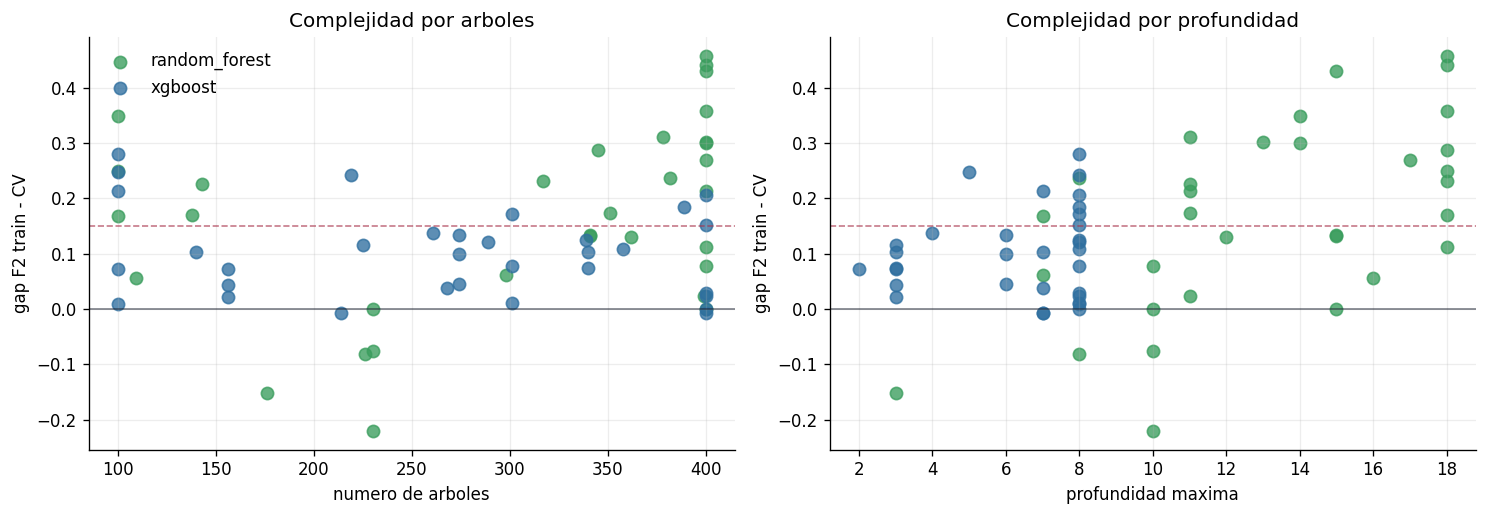

In [ ]:

detail_cols = [
    "model_label", "n_train", "wr_train", "n_holdout", "wr_holdout",
    "holdout_wr_at_10_pct", "holdout_wr_at_50_pct", "holdout_wr_at_100_pct",
    "cv_train_gap_f2", "holdout_cv_gap_f2", "selection_status", "hyperparams_compact",
]
display(top[detail_cols].style.format({
    "holdout_wr_at_10_pct": "{:.1%}",
    "holdout_wr_at_50_pct": "{:.1%}",
    "holdout_wr_at_100_pct": "{:.1%}",
    "cv_train_gap_f2": "{:.3f}",
    "holdout_cv_gap_f2": "{:.3f}",
}))

model_complexity = (
    results.groupby("model", dropna=False)
    .agg(
        configs=("model_label", "size"),
        n_estimators_mean=("n_estimators", "mean"),
        n_estimators_median=("n_estimators", "median"),
        n_estimators_min=("n_estimators", "min"),
        n_estimators_max=("n_estimators", "max"),
        max_depth_mean=("max_depth", "mean"),
        max_depth_median=("max_depth", "median"),
        cv_train_gap_f2_mean=("cv_train_gap_f2", "mean"),
        cv_train_gap_f2_max=("cv_train_gap_f2", "max"),
        holdout_cv_gap_f2_mean=("holdout_cv_gap_f2", "mean"),
        overfit_warning_rate=("overfit_warning_flag", "mean"),
    )
    .sort_values("cv_train_gap_f2_mean", ascending=False)
)
display(model_complexity.style.format({
    "n_estimators_mean": "{:.1f}",
    "n_estimators_median": "{:.0f}",
    "n_estimators_min": "{:.0f}",
    "n_estimators_max": "{:.0f}",
    "max_depth_mean": "{:.1f}",
    "max_depth_median": "{:.0f}",
    "cv_train_gap_f2_mean": "{:.3f}",
    "cv_train_gap_f2_max": "{:.3f}",
    "holdout_cv_gap_f2_mean": "{:.3f}",
    "overfit_warning_rate": "{:.1%}",
}))

plot_df = results.dropna(subset=["n_estimators", "max_depth", "cv_train_gap_f2"]).copy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for model_name, group in plot_df.groupby("model"):
    color = PALETTE.get(model_name, PALETTE["muted"])
    axes[0].scatter(group["n_estimators"], group["cv_train_gap_f2"], s=54, alpha=0.78, color=color, label=model_name)
    axes[1].scatter(group["max_depth"], group["cv_train_gap_f2"], s=54, alpha=0.78, color=color, label=model_name)
for ax in axes:
    ax.axhline(0, color="#111827", lw=1, alpha=0.55)
    ax.axhline(0.15, color="#A8324A", lw=1, ls="--", alpha=0.65)
    ax.set_ylabel("gap F2 train - CV")
axes[0].set_xlabel("numero de arboles")
axes[1].set_xlabel("profundidad maxima")
axes[0].set_title("Complejidad por arboles")
axes[1].set_title("Complejidad por profundidad")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()


## Gaps de estabilidad


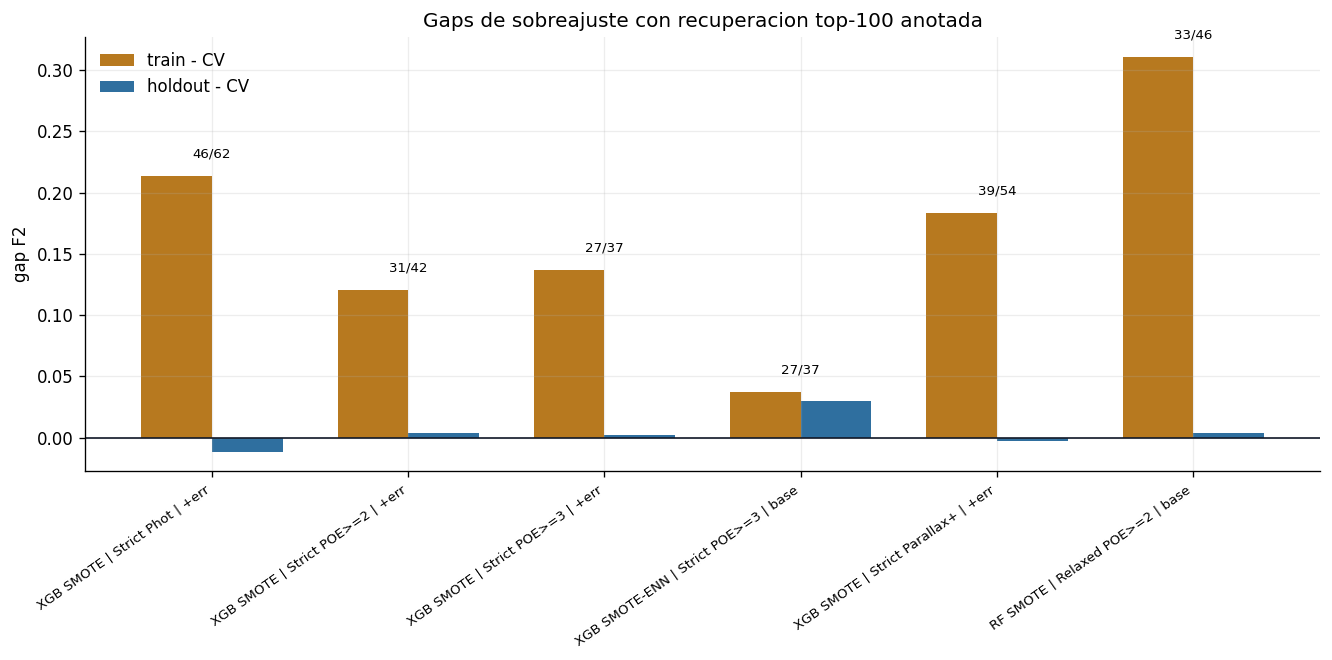

In [ ]:
fig, ax = plt.subplots(figsize=(11.2, 5.6))
x = np.arange(len(top)); width = 0.36
ax.bar(x - width/2, top["cv_train_gap_f2"], width=width, color="#B7791F", label="train - CV")
ax.bar(x + width/2, top["holdout_cv_gap_f2"], width=width, color="#2F6F9F", label="holdout - CV")
for i, row in top.iterrows():
    ax.text(i, max(row["cv_train_gap_f2"], row["holdout_cv_gap_f2"], 0) + 0.015, f"{int(row['holdout_wr_at_100'])}/{int(row['wr_holdout'])}", ha="center", fontsize=8)
ax.axhline(0, color="#111827", lw=1)
ax.set_xticks(x, top["model_label"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("gap F2")
ax.set_title("Gaps de sobreajuste con recuperacion top-100 anotada")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Metricas train, CV y holdout


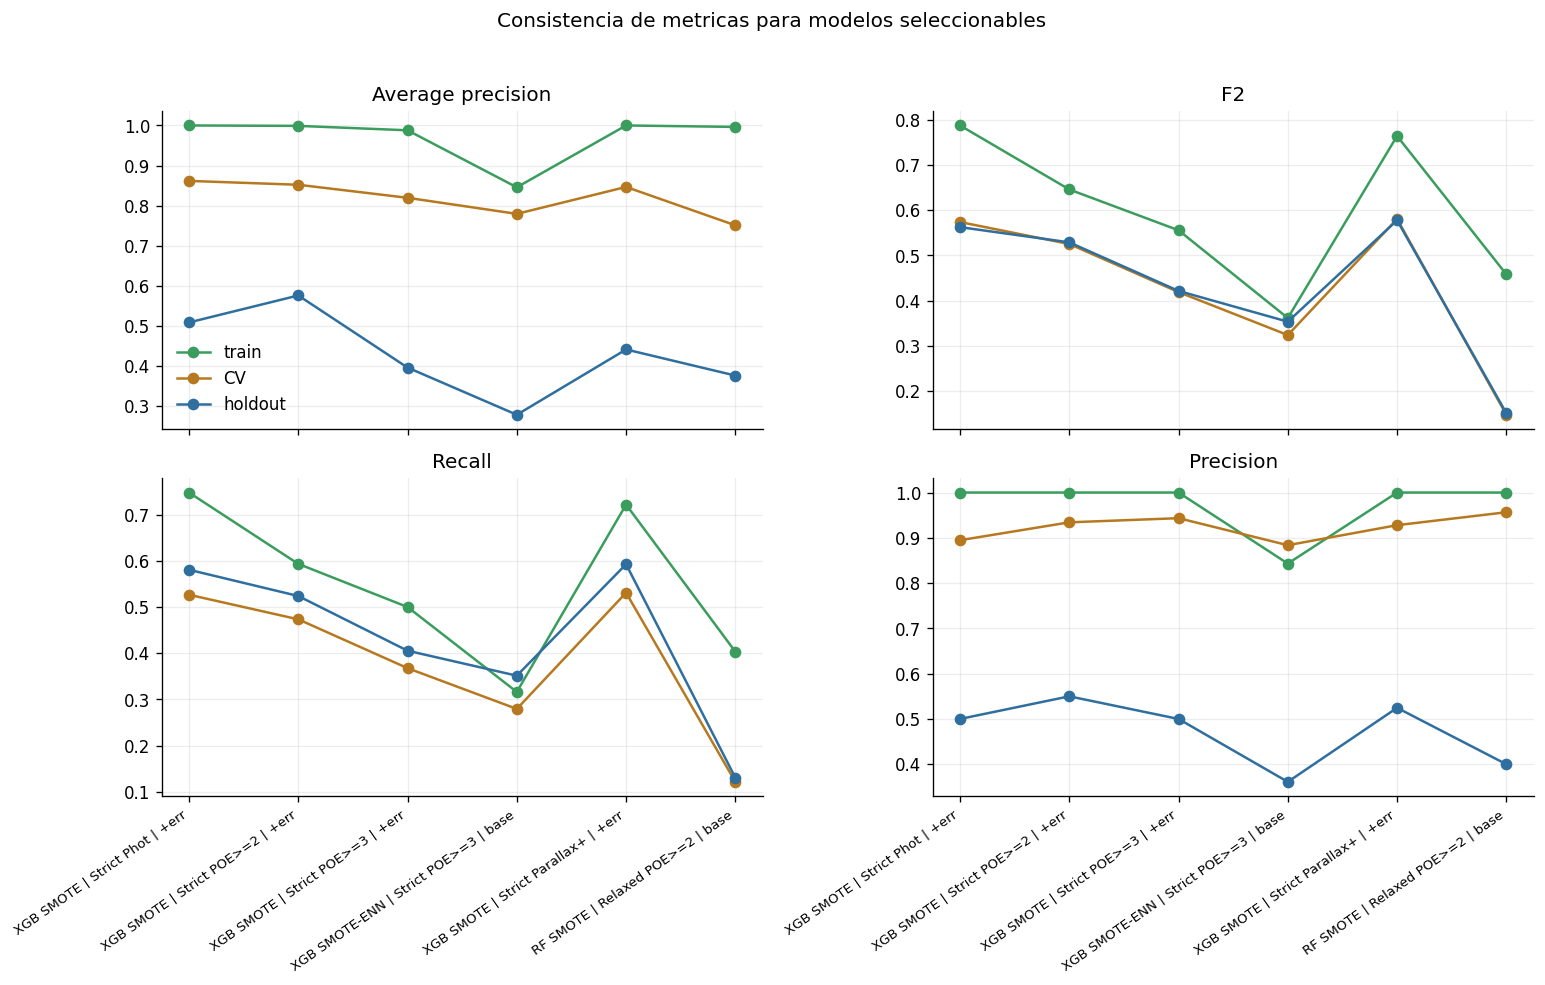

In [ ]:
metrics = ["average_precision", "f2_wr", "recall_wr", "precision_wr"]
labels = ["Average precision", "F2", "Recall", "Precision"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, metric, label in zip(axes.ravel(), metrics, labels):
    x = np.arange(len(top))
    ax.plot(x, top[f"train_{metric}"], marker="o", label="train", color="#3A9D5D")
    ax.plot(x, top[f"cv_{metric}"], marker="o", label="CV", color="#B7791F")
    ax.plot(x, top[f"holdout_{metric}"], marker="o", label="holdout", color="#2F6F9F")
    ax.set_title(label)
    ax.set_xticks(x, top["model_label"], rotation=35, ha="right", fontsize=8)
axes[0, 0].legend(frameon=False)
fig.suptitle("Consistencia de metricas para modelos seleccionables", y=1.02)
plt.tight_layout()
plt.show()


## Confusiones SIMBAD del top auditado

Falsos positivos del holdout agrupados por tipo SIMBAD para los modelos auditados.

In [ ]:

rows = []
for _, row in top.iterrows():
    joined = load_holdout_with_predictions(row)
    fp = joined[(joined.get("target", pd.Series(dtype=int)).eq(0)) & (joined.get("predicted", pd.Series(dtype=int)).eq(1))]
    for col in ["simbad_main_type", "simbad_query_type"]:
        if col not in fp.columns:
            continue
        for label, count in fp[col].fillna("missing").value_counts().head(8).items():
            rows.append({"model_label": row["model_label"], "field": col, "type": label, "false_positive_rows": int(count), "total_false_positives": int(len(fp))})
fp_audit = pd.DataFrame(rows)
if fp_audit.empty:
    display(Markdown("Sin falsos positivos trazables en el top auditado."))
else:
    display(fp_audit)


,model_label,field,type,false_positive_rows,total_false_positives
0,XGB SMOTE | Strict Phot | +err,simbad_main_type,Em*,16,36
1,XGB SMOTE | Strict Phot | +err,simbad_main_type,Be*,6,36
2,XGB SMOTE | Strict Phot | +err,simbad_main_type,HXB,5,36
3,XGB SMOTE | Strict Phot | +err,simbad_main_type,Y*O,4,36
4,XGB SMOTE | Strict Phot | +err,simbad_main_type,AB*,4,36
5,XGB SMOTE | Strict Phot | +err,simbad_main_type,LP*,1,36
6,XGB SMOTE | Strict Phot | +err,simbad_query_type,EmLine*,16,36
7,XGB SMOTE | Strict Phot | +err,simbad_query_type,Be*,6,36
8,XGB SMOTE | Strict Phot | +err,simbad_query_type,HighMassXBin,5,36
9,XGB SMOTE | Strict Phot | +err,simbad_query_type,YSO,4,36


## Subtipos WR menos reconocidos

Subtipo desde Crowther/GWRC (`Spectral Type`) cruzado por `source_id`. Se usa el umbral del modelo para detectar familias/subtipos con baja recuperacion.

In [ ]:

rows = []
for _, row in top.iterrows():
    joined = load_holdout_with_predictions(row)
    wr = joined[joined.get("target", pd.Series(dtype=int)).eq(1)].copy()
    for col in ["wr_family", "spectral_type"]:
        if col not in wr.columns:
            continue
        g = wr.groupby(col, dropna=False).agg(wr_holdout=("source_id", "size"), wr_recovered=("predicted", "sum"), median_score=("score", "median")).reset_index().rename(columns={col: "wr_type"})
        g["recall_at_threshold"] = g["wr_recovered"] / g["wr_holdout"].replace(0, np.nan)
        g.insert(0, "grouping", col)
        g.insert(0, "model_label", row["model_label"])
        rows.extend(g.to_dict("records"))
wr_type_audit = pd.DataFrame(rows)
if wr_type_audit.empty:
    display(Markdown("Sin WR trazables a subtipo en el top auditado."))
else:
    display(wr_type_audit.sort_values(["grouping", "recall_at_threshold", "wr_holdout"], ascending=[True, True, False]).head(40).style.format({"recall_at_threshold": "{:.1%}", "median_score": "{:.3f}"}))


,model_label,grouping,wr_type,wr_holdout,wr_recovered,median_score,recall_at_threshold
198,RF SMOTE | Relaxed POE>=2 | base,spectral_type,WC9,3,0,0.957,0.0%
212,RF SMOTE | Relaxed POE>=2 | base,spectral_type,WN6o,3,0,0.506,0.0%
194,RF SMOTE | Relaxed POE>=2 | base,spectral_type,WC6,2,0,0.909,0.0%
13,XGB SMOTE | Strict Phot | +err,spectral_type,WC9d,1,0,0.127,0.0%
14,XGB SMOTE | Strict Phot | +err,spectral_type,WC9d; WC9vd,1,0,0.031,0.0%
15,XGB SMOTE | Strict Phot | +err,spectral_type,WCE,1,0,0.959,0.0%
21,XGB SMOTE | Strict Phot | +err,spectral_type,WN5-6b,1,0,0.969,0.0%
25,XGB SMOTE | Strict Phot | +err,spectral_type,WN5o+O5V-III,1,0,0.121,0.0%
27,XGB SMOTE | Strict Phot | +err,spectral_type,WN6+O6.5V; WN6+abs,1,0,0.009,0.0%
28,XGB SMOTE | Strict Phot | +err,spectral_type,"WN6, WN5b",1,0,0.243,0.0%


## Importancia de features


### XGB SMOTE | Strict Phot | +err

,feature,importance_mean,importance_std,importance_type
0,W1_W2,0.3740,0.0000,model_feature_importance
1,parallax,0.1600,0.0000,model_feature_importance
2,parallax_over_error,0.0792,0.0000,model_feature_importance
3,G_RP,0.0760,0.0000,model_feature_importance
4,H_K,0.0720,0.0000,model_feature_importance
5,J_H,0.0605,0.0000,model_feature_importance
6,parallax_error,0.0574,0.0000,model_feature_importance
7,BP_RP,0.0427,0.0000,model_feature_importance
8,G_BP,0.0392,0.0000,model_feature_importance
9,J_K,0.0390,0.0000,model_feature_importance


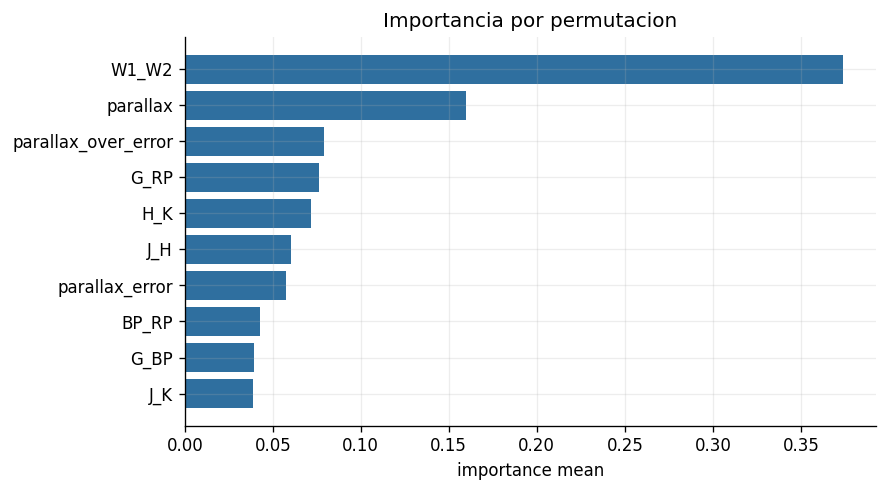

### XGB SMOTE | Strict POE>=2 | +err

,feature,importance_mean,importance_std,importance_type
0,parallax,0.4908,0.0000,model_feature_importance
1,W1_W2,0.1969,0.0000,model_feature_importance
2,H_K,0.0476,0.0000,model_feature_importance
3,J_H,0.0447,0.0000,model_feature_importance
4,J_K,0.0444,0.0000,model_feature_importance
5,BP_RP,0.0396,0.0000,model_feature_importance
6,G_RP,0.0385,0.0000,model_feature_importance
7,G_BP,0.0342,0.0000,model_feature_importance
8,parallax_over_error,0.0337,0.0000,model_feature_importance
9,parallax_error,0.0295,0.0000,model_feature_importance


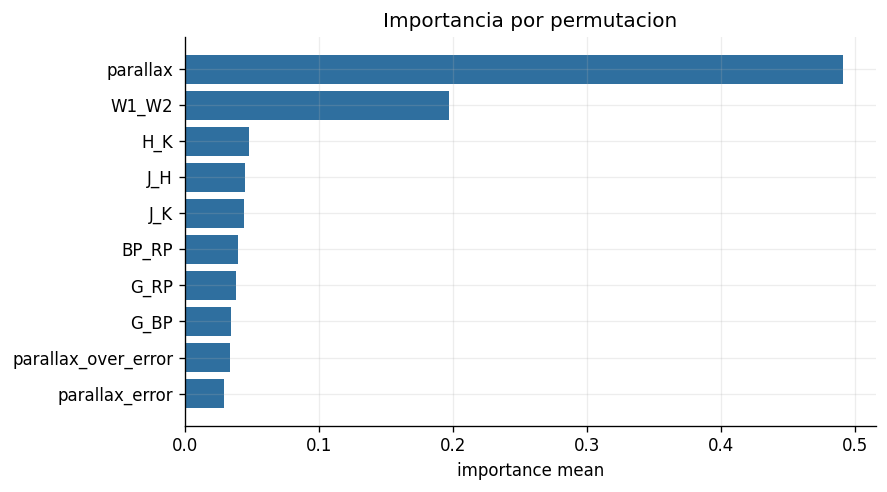

### XGB SMOTE | Strict POE>=3 | +err

,feature,importance_mean,importance_std,importance_type
0,parallax,0.3478,0.0000,model_feature_importance
1,W1_W2,0.2661,0.0000,model_feature_importance
2,H_K,0.0874,0.0000,model_feature_importance
3,parallax_error,0.0588,0.0000,model_feature_importance
4,parallax_over_error,0.0581,0.0000,model_feature_importance
5,G_BP,0.0428,0.0000,model_feature_importance
6,J_H,0.0407,0.0000,model_feature_importance
7,BP_RP,0.0393,0.0000,model_feature_importance
8,J_K,0.0323,0.0000,model_feature_importance
9,G_RP,0.0267,0.0000,model_feature_importance


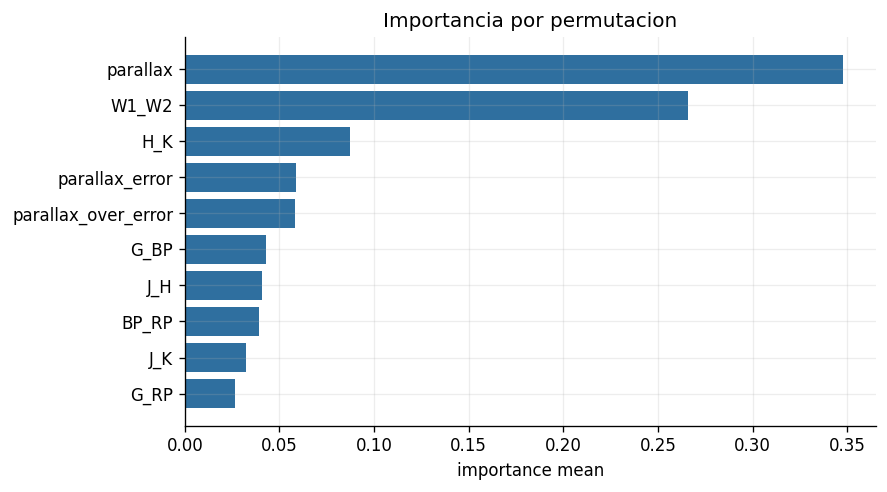

### XGB SMOTE-ENN | Strict POE>=3 | base

,feature,importance_mean,importance_std,importance_type
0,parallax,0.3362,0.0000,model_feature_importance
1,W1_W2,0.2136,0.0000,model_feature_importance
2,H_K,0.1613,0.0000,model_feature_importance
3,J_K,0.0998,0.0000,model_feature_importance
4,BP_RP,0.0614,0.0000,model_feature_importance
5,G_BP,0.0491,0.0000,model_feature_importance
6,J_H,0.0417,0.0000,model_feature_importance
7,G_RP,0.0370,0.0000,model_feature_importance


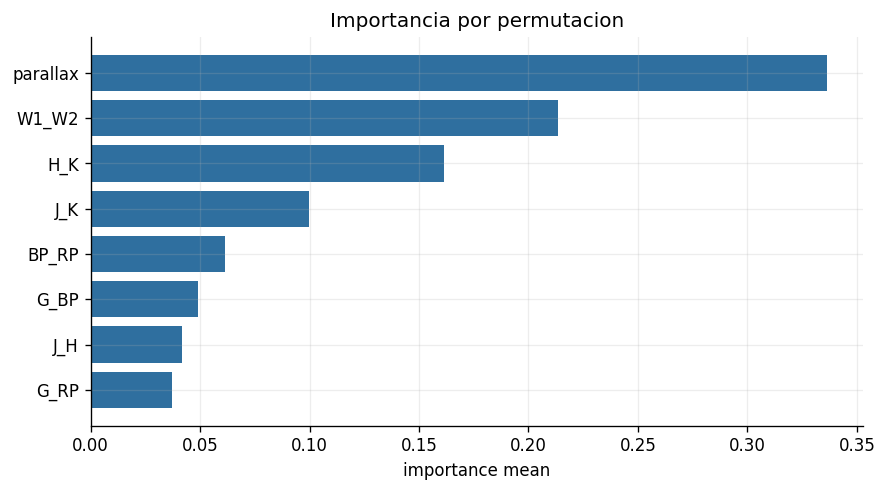

In [ ]:
def load_importance(row):
    p = ROOT / str(row.get("feature_importance_path", ""))
    if p.exists():
        return pd.read_csv(p)
    db = ROOT / "data/databases/training_history.duckdb"
    if db.exists():
        con = duckdb.connect(str(db), read_only=True)
        try:
            return con.execute('''
                SELECT feature, importance_mean, importance_std, importance_type
                FROM feature_importance
                WHERE dataset_variant = ? AND feature_set = ? AND model = ? AND sampler = ?
                ORDER BY importance_mean DESC
            ''', [row.dataset_variant, row.feature_set, row.model, row.sampler]).fetchdf()
        finally:
            con.close()
    return pd.DataFrame()

for _, row in top.head(4).iterrows():
    display(Markdown(f"### {row['model_label']}"))
    imp = load_importance(row)
    if imp.empty:
        display(Markdown("Sin importancia disponible."))
        continue
    display(imp.head(10).style.format(precision=4))
    plot = imp.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.barh(plot["feature"], plot["importance_mean"], xerr=plot.get("importance_std"), color=PALETTE.get(row["model"], PALETTE["muted"]))
    ax.set_title("Importancia por permutacion")
    ax.set_xlabel("importance mean")
    plt.tight_layout()
    plt.show()
